## 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

## 2. Load Dataset

In [5]:
df = pd.read_csv("retail_sales_dataset.csv")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


## 3. Basic information()

In [6]:
df.shape

(1000, 9)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


In [8]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [9]:
df.sample(5)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
905,906,2023-06-04,CUST906,Female,20,Clothing,1,50,50
407,408,2023-04-15,CUST408,Female,64,Beauty,1,500,500
743,744,2023-05-07,CUST744,Male,40,Electronics,1,25,25
985,986,2023-01-17,CUST986,Female,49,Clothing,2,500,1000
544,545,2023-06-01,CUST545,Male,27,Clothing,2,25,50


## 4. Missing Values

In [10]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

## 5. Duplicate Values

In [12]:
df.duplicated().sum()

np.int64(0)

## 6. Convert Date

In [13]:
df["Date"] = pd.to_datetime(df["Date"])

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[us]
 2   Customer ID       1000 non-null   str           
 3   Gender            1000 non-null   str           
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   str           
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[us](1), int64(5), str(3)
memory usage: 70.4 KB


## 7. Rename Columns

In [15]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='str')

In [16]:
df.columns = (
    df.columns
      .str.lower()
      .str.strip()
      .str.replace(" ","_")
)

In [17]:
df.columns

Index(['transaction_id', 'date', 'customer_id', 'gender', 'age',
       'product_category', 'quantity', 'price_per_unit', 'total_amount'],
      dtype='str')

## 8. Data Types

In [19]:
df.dtypes

transaction_id               int64
date                datetime64[us]
customer_id                    str
gender                         str
age                          int64
product_category               str
quantity                     int64
price_per_unit               int64
total_amount                 int64
dtype: object

## 9. Unique Values

In [20]:
for col in df.columns:
    print(col)
    print(df[col].unique)
    print("-"*50)

transaction_id
<bound method Series.unique of 0         1
1         2
2         3
3         4
4         5
       ... 
995     996
996     997
997     998
998     999
999    1000
Name: transaction_id, Length: 1000, dtype: int64>
--------------------------------------------------
date
<bound method Series.unique of 0     2023-11-24
1     2023-02-27
2     2023-01-13
3     2023-05-21
4     2023-05-06
         ...    
995   2023-05-16
996   2023-11-17
997   2023-10-29
998   2023-12-05
999   2023-04-12
Name: date, Length: 1000, dtype: datetime64[us]>
--------------------------------------------------
customer_id
<bound method Series.unique of 0       CUST001
1       CUST002
2       CUST003
3       CUST004
4       CUST005
         ...   
995     CUST996
996     CUST997
997     CUST998
998     CUST999
999    CUST1000
Name: customer_id, Length: 1000, dtype: str>
--------------------------------------------------
gender
<bound method Series.unique of 0        Male
1      Female
2        Male
3  

## 10. Check Outliers

In [21]:
numerical_cols = [
    "age",
    "quantity",
    "price_per_unit",
    "total_amount"
]

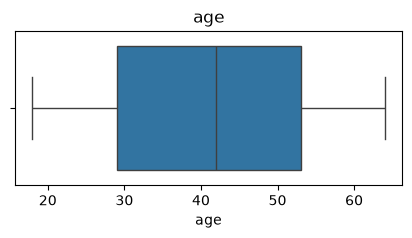

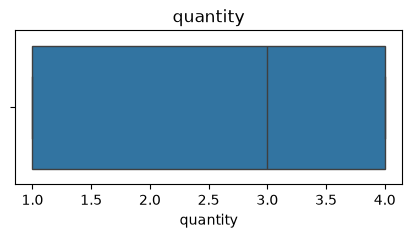

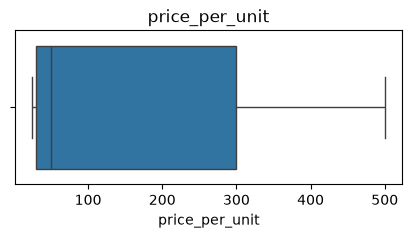

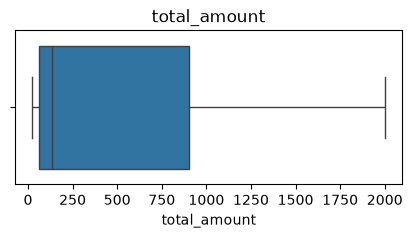

In [22]:
for col in numerical_cols:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

## 12. Feature Engineering

# 1. Year

In [24]:
df["year"] = df["date"].dt.year

# 2. Month Number

In [25]:
df["month"] = df["date"].dt.month

# 3. Month Name

In [38]:
df["month_name"] = df["date"].dt.month_name()

# 4. Day

In [27]:
df["day"] = df["date"].dt.day

# 5. Day Name

In [28]:
df["day_name"] = df["date"].dt.day_name()

# 6. Quarter

In [29]:
df["quarter"] = df["date"].dt.quarter

# 7. Weekand

In [30]:
df["is_weekend"] = df["day_name"].isin(
    ["Saturday", "Sunday"]
)

# 8. Age Group

In [31]:
bins = [0,18,25,35,58,100]

labels = [
    "Teen",
    "Young Adult",
    "Adult",
    "Middle Age",
    "Senior"
]

df["age_group"] = pd.cut(
    df["age"],
    bins=bins,
    labels=labels
)

## 13. Final Check

In [32]:
df.head()

,transaction_id,date,customer_id,gender,age,product_category,quantity,price_per_unit,total_amount,year,month,month_year,day,day_name,quarter,is_weekend,age_group
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,2023,11,November,24,Friday,4,False,Adult
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2023,2,February,27,Monday,1,False,Adult
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,2023,1,January,13,Friday,1,False,Middle Age
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,2023,5,May,21,Sunday,2,True,Middle Age
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,2023,5,May,6,Saturday,2,True,Adult


In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    1000 non-null   int64         
 1   date              1000 non-null   datetime64[us]
 2   customer_id       1000 non-null   str           
 3   gender            1000 non-null   str           
 4   age               1000 non-null   int64         
 5   product_category  1000 non-null   str           
 6   quantity          1000 non-null   int64         
 7   price_per_unit    1000 non-null   int64         
 8   total_amount      1000 non-null   int64         
 9   year              1000 non-null   int32         
 10  month             1000 non-null   int32         
 11  month_year        1000 non-null   str           
 12  day               1000 non-null   int32         
 13  day_name          1000 non-null   str           
 14  quarter           1000 non-null   in

In [34]:
df.describe()

,transaction_id,date,age,quantity,price_per_unit,total_amount,year,month,day,quarter
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000,41.39200,2.514000,179.890000,456.000000,2023.002000,6.549000,15.310000,2.525000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000,2023.000000,1.000000,1.000000,1.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000,2023.000000,4.000000,7.000000,2.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000,2023.000000,6.000000,15.000000,2.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000,2023.000000,10.000000,23.000000,4.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000,2024.000000,12.000000,31.000000,4.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632,0.044699,3.452755,8.871674,1.119208


## 14. Save Clean Dataset

In [42]:
df.to_csv(
    "Retail_Sales_cleaned.csv",
    index = False
)